# Exploratory Data Analysis (EDA)

In this notebook, we explore the Saudi job market dataset to identify patterns, relationships, and insights through descriptive analysis and data visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/Jadarat_cleaned.csv")

# Business Questions

This exploratory data analysis aims to answer the following questions:

1. Where are job opportunities concentrated in Saudi Arabia?
2. What company sizes post the most job opportunities?
3. What are the most common job titles?
4. How is gender preference distributed across job postings?
5. What types of employment contracts are most common?

## Business Question 1

### Where are job opportunities concentrated in Saudi Arabia?

This analysis aims to identify the cities and regions with the highest number of job postings.

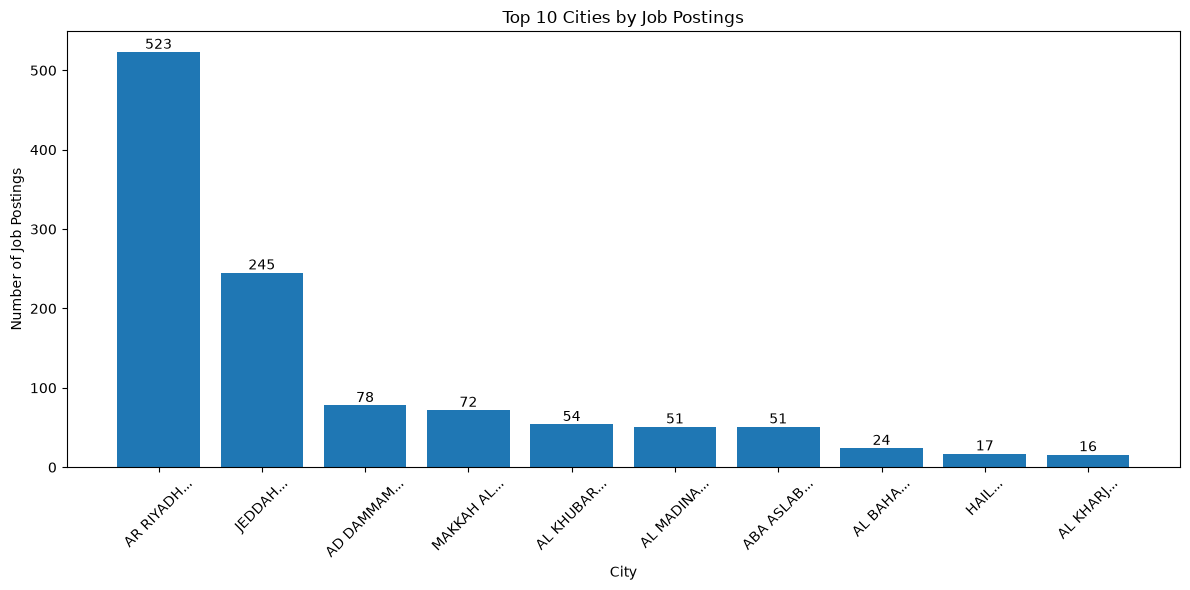

In [3]:
city_counts = df["city"].value_counts().head(10) 

plt.figure(figsize=(12,6))

bars = plt.bar(city_counts.index, city_counts.values)

plt.title("Top 10 Cities by Job Postings")
plt.xlabel("City")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()


### Insight

- Riyadh has the highest number of job postings (523), significantly exceeding all other cities.
- Jeddah ranks second with 245 job postings.
- The large gap between Riyadh and other cities indicates that employment opportunities are highly concentrated in the capital.

## Business Question 2

### Which job titles are most in demand?

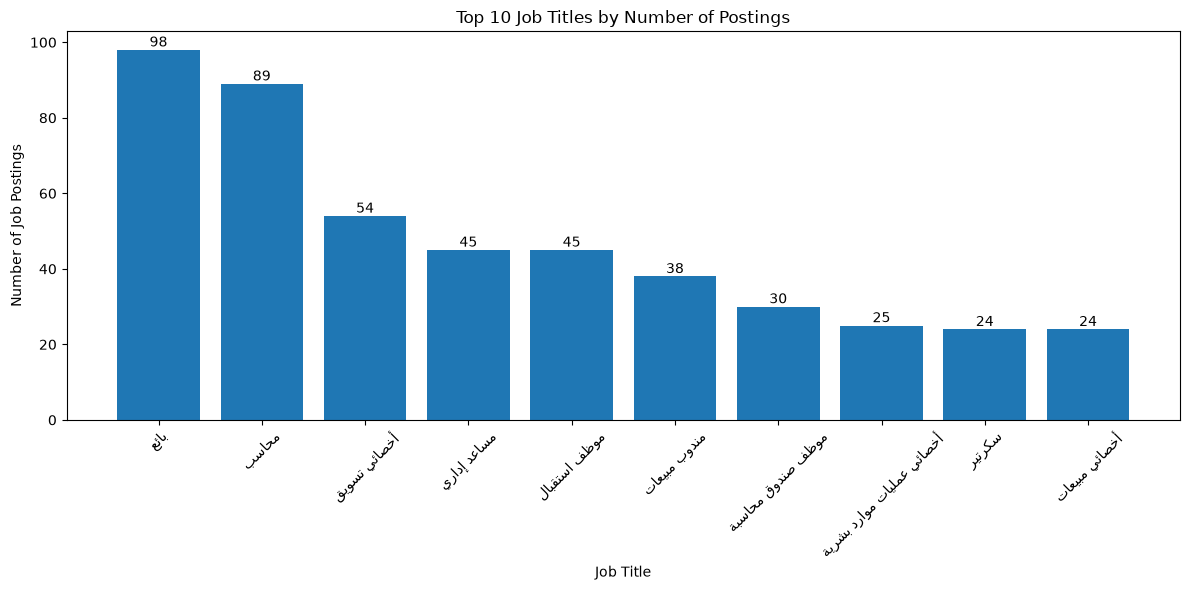

In [4]:
jobs_counts = df["job_title"].value_counts().head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(jobs_counts.index, jobs_counts.values)

plt.title("Top 10 Job Titles by Number of Postings")
plt.xlabel("Job Title")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Insight

- Salesperson is the most frequently advertised job title in the dataset.
- Accountant ranks second, followed by Marketing Specialist.
- The results indicate that sales, finance, and marketing positions are among the most in-demand occupations in the Saudi job market.

## Business Question 3

### How are job opportunities distributed by gender?

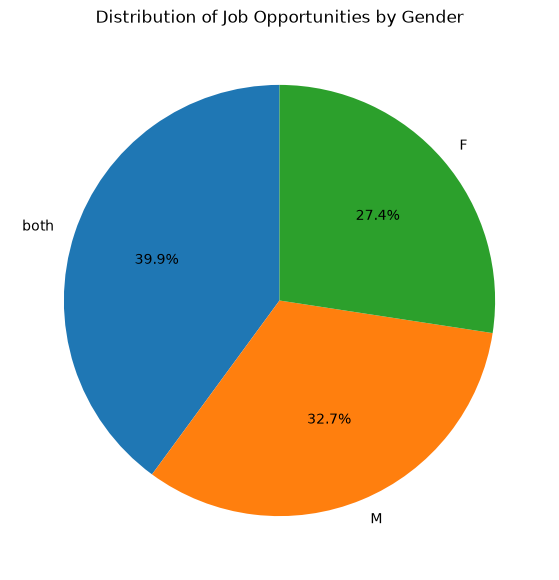

In [5]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Job Opportunities by Gender")

plt.show()

### Insight

Most job postings in the dataset are open to both genders, indicating that many employers do not specify gender requirements.
Male-only and female-only job postings represent smaller portions of the total vacancies.
This suggests that a large share of employment opportunities in the Saudi job market is advertised as gender-inclusive.

## Business Question 4

### Which job titles are most common for each gender?

In [6]:
top_jobs_by_gender = (
    df.groupby("gender")["job_title"]
      .value_counts()
      .groupby(level=0)
      .head(5)
)

top_jobs_by_gender

gender  job_title                   
F       محاسب                           32
        موظف استقبال                    29
        بائع                            23
        أخصائي تسويق                    20
        مساعد إداري                     19
M       بائع                            36
        محاسب                           19
        مهندس مدني                      19
        مساعد إداري                     10
        مهندس ميكانيكي                  10
both    بائع                            39
        محاسب                           38
        أخصائي تسويق                    27
        موظف صندوق محاسبة               17
        عامل كاونتر مأكولات ومشروبات    16
Name: count, dtype: int64

### Insight

The most common job titles differ across gender categories. Male-targeted postings are dominated by sales and engineering roles, while female-targeted postings are more concentrated in accounting, reception, marketing, and administrative positions. Jobs open to both genders are primarily in sales, accounting, and marketing, suggesting that these occupations are generally advertised without gender restrictions.

## Business Question 5

### Which regions have the greatest variety of job titles?

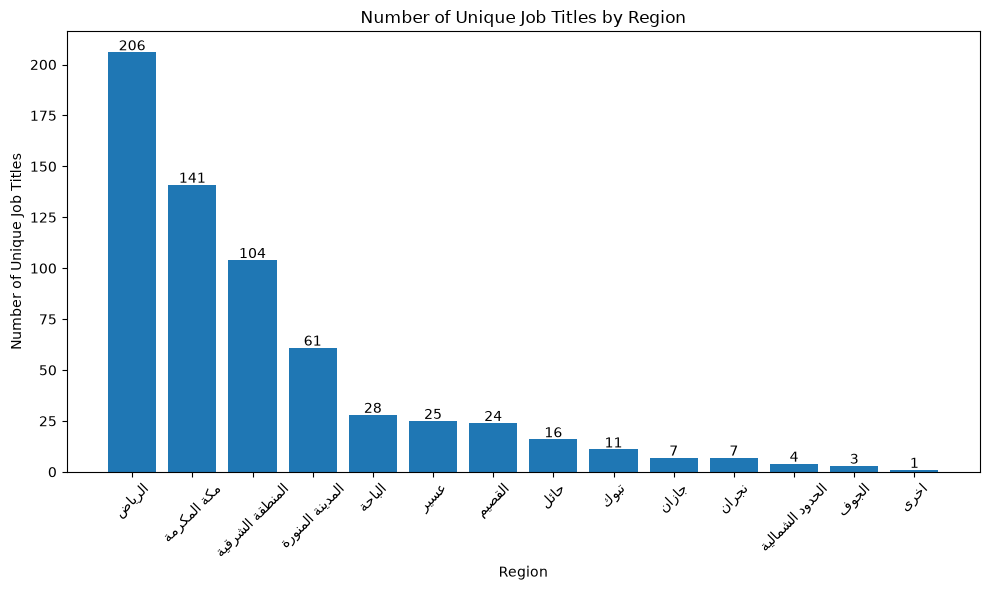

In [11]:
job_variety = (
    df.groupby("region")["job_title"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(job_variety.index, job_variety.values)

plt.title("Number of Unique Job Titles by Region")
plt.xlabel("Region")
plt.ylabel("Number of Unique Job Titles")

plt.xticks(rotation=45)

for i, value in enumerate(job_variety.values):
    plt.text(i, value + 1, str(value), ha="center")

plt.tight_layout()
plt.show()

### Insight

Riyadh has the greatest variety of job titles, with 206 unique roles, followed by Makkah (141) and the Eastern Region (104).

The large gap between these regions and the rest suggests that job opportunities are not only more numerous but also more diverse in Saudi Arabia's major economic centers.

Smaller regions offer a much narrower range of occupations, indicating that job seekers with specialized skills may have more opportunities in larger metropolitan areas.

### Comparative Analysis

Although Riyadh and Makkah both have a high number of job postings, Riyadh also demonstrates a substantially wider variety of job titles (206 vs. 141). This suggests that Riyadh's labor market is more diversified, offering opportunities across a broader range of professions rather than concentrating on a limited set of occupations.

### Business Recommendation

Job seekers looking for a wider range of career opportunities may prioritize Riyadh, Makkah, and the Eastern Region, as these regions provide the most diverse job markets. Employers seeking specialized talent may also benefit from focusing recruitment efforts in these regions.

## Business Question 6

### Which industries advertise the highest number of job postings?

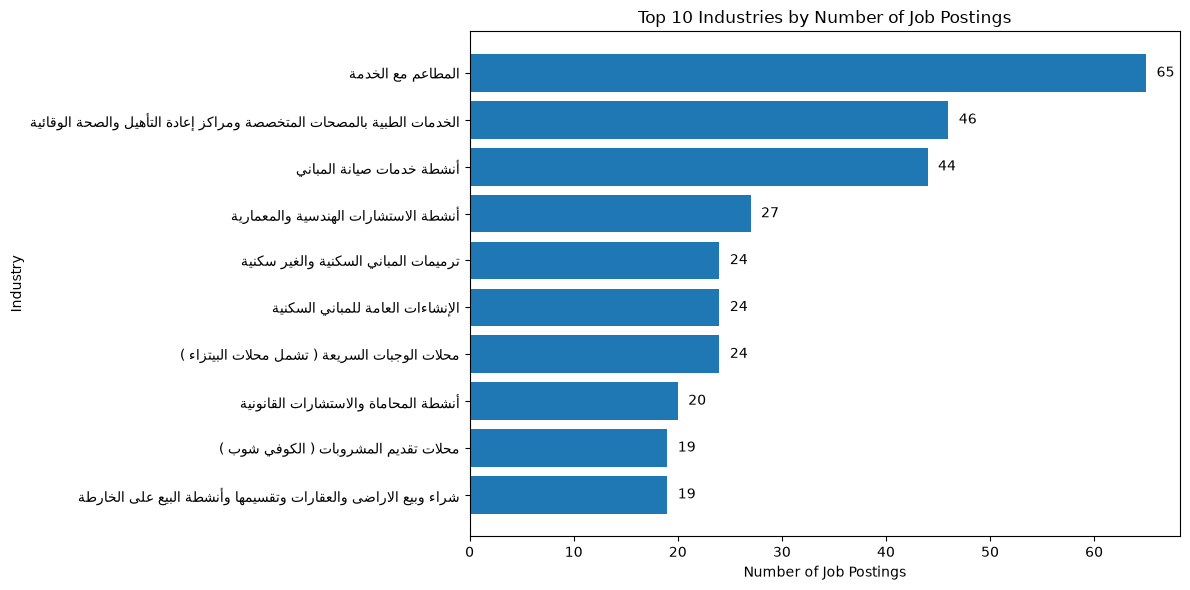

In [10]:
industry_counts = df["eco_activity"].value_counts().head(10)

plt.figure(figsize=(12, 6))

plt.barh(industry_counts.index, industry_counts.values)

plt.gca().invert_yaxis()

plt.title("Top 10 Industries by Number of Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Industry")

for i, value in enumerate(industry_counts.values):
    plt.text(value + 1, i, str(value), va="center")

plt.tight_layout()
plt.show()

### Insight

The restaurant industry has the highest number of job postings, followed by healthcare services and building maintenance services. This suggests that service-oriented industries are among the most active employers in the Saudi job market. Engineering and construction-related activities also appear frequently, indicating consistent demand for technical and infrastructure-related occupations.

## Business Question 7

### Which industries offer the widest variety of job opportunities?

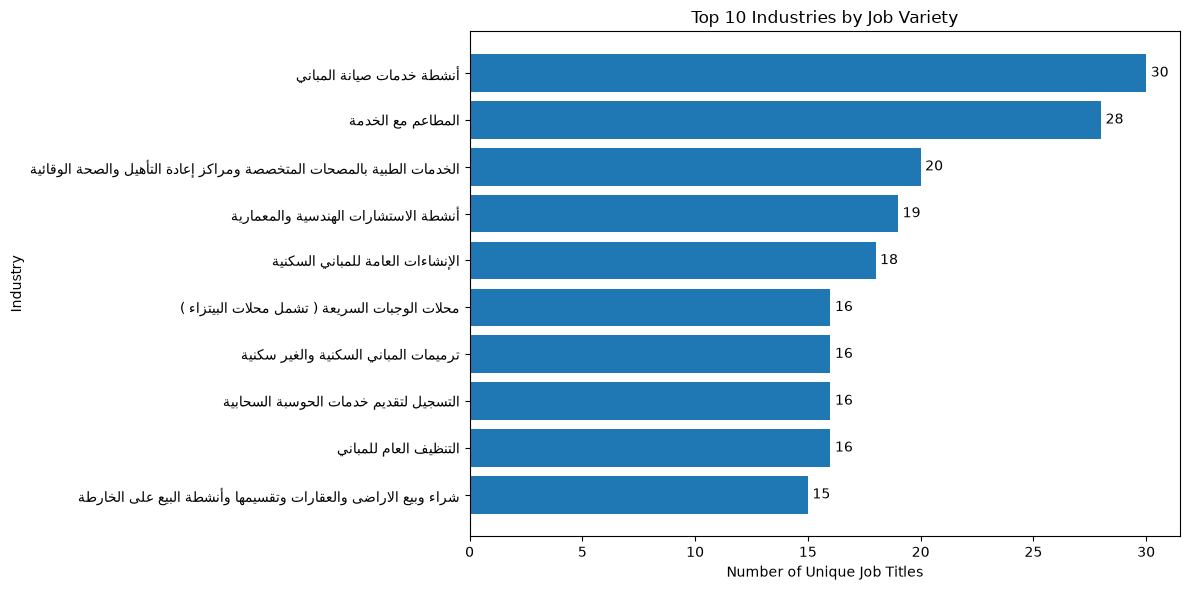

In [30]:
industry_variety = (
    df.groupby("eco_activity")["job_title"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))

plt.barh(industry_variety.index, industry_variety.values)

plt.gca().invert_yaxis()

plt.title("Top 10 Industries by Job Variety")
plt.xlabel("Number of Unique Job Titles")
plt.ylabel("Industry")

for i, value in enumerate(industry_variety.values):
    plt.text(value + 0.2, i, str(value), va="center")

plt.tight_layout()
plt.show()

### Insight

Building maintenance services offer the widest variety of job opportunities, followed by the restaurant industry and specialized healthcare services. While the restaurant industry posts the largest number of vacancies, building maintenance demonstrates greater diversity in job roles, suggesting demand for a broader range of skills and occupations.

## Business Question 8

### How are job postings distributed by gender across the top industries?

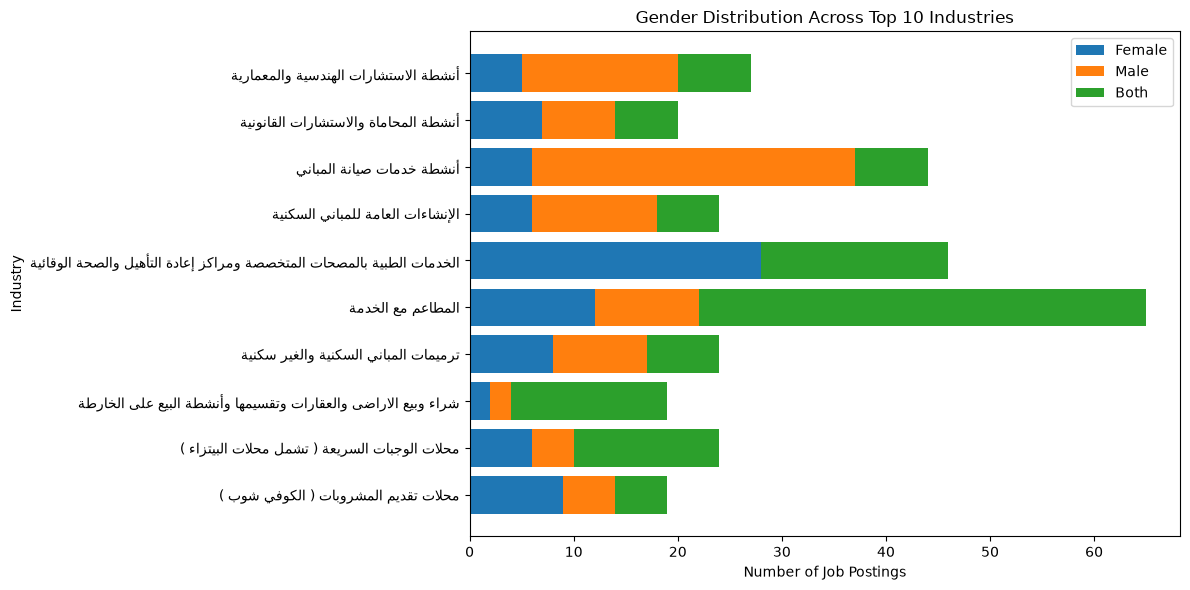

In [29]:
# Get the top 10 industries
top10_industries = industry_counts.index

# Filter the dataset
df_top10 = df[df["eco_activity"].isin(top10_industries)]

# Create the cross-tabulation
industry_gender = pd.crosstab(
    df_top10["eco_activity"],
    df_top10["gender"]
)

plt.figure(figsize=(12, 6))

# Female
plt.barh(
    industry_gender.index,
    industry_gender["F"],
    label="Female"
)

# Male
plt.barh(
    industry_gender.index,
    industry_gender["M"],
    left=industry_gender["F"],
    label="Male"
)

# Both
plt.barh(
    industry_gender.index,
    industry_gender["both"],
    left=industry_gender["F"] + industry_gender["M"],
    label="Both"
)

plt.gca().invert_yaxis()

plt.title("Gender Distribution Across Top 10 Industries")
plt.xlabel("Number of Job Postings")
plt.ylabel("Industry")

plt.legend()

plt.tight_layout()
plt.show()

### Insight

The restaurant industry has the highest number of gender-neutral job postings, suggesting a more inclusive hiring approach. In contrast, healthcare vacancies are primarily targeted toward female applicants, while building maintenance jobs are predominantly advertised for male candidates. These differences indicate that hiring preferences vary considerably across industries.

### Comparative Analysis

Compared with other industries, restaurants demonstrate the most balanced hiring pattern by offering many positions open to both genders. On the other hand, healthcare and building maintenance show stronger gender-specific recruitment trends, reflecting different workforce requirements.

### Business Recommendation

Employers can benchmark their hiring practices against industry trends to encourage inclusive recruitment where appropriate. Job seekers can also use these insights to focus on industries that best match their qualifications and employment preferences.